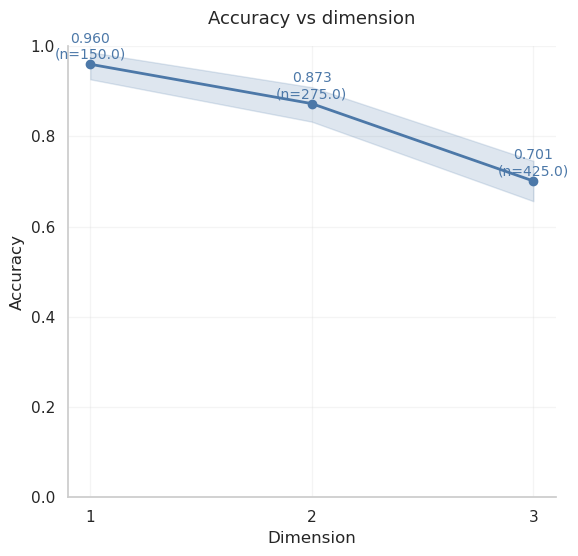

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

assert 'df_trials' in globals() and not df_trials.empty, "Run the data loading cell first."

# Aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (6, 6),
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
out_dir = "/scratch/gpfs/nb0564/vlm_reasoning/plots"
os.makedirs(out_dir, exist_ok=True)

def bootstrap_ci_mean(binary_series, n_boot=2000, alpha=0.05):
    a = binary_series.astype(int).values
    if a.size == 0:
        return np.nan, np.nan, np.nan
    boots = np.random.choice(a, size=(n_boot, a.size), replace=True).mean(axis=1)
    return float(a.mean()), float(np.percentile(boots, 100*alpha/2)), float(np.percentile(boots, 100*(1-alpha/2)))

# Aggregate across ALL variance levels at each logical dimension (concat all trials)
dims_present = sorted(df_trials['logical_dim'].unique())
rows = []
for ld in [1, 2, 3]:
    s = df_trials[df_trials['logical_dim'] == ld]['correct']
    if s.empty:
        continue
    m, lo, hi = bootstrap_ci_mean(s, n_boot=2000, alpha=0.05)
    rows.append((ld, m, lo, hi, len(s)))
P = pd.DataFrame(rows, columns=['logical_dim','mean','lo','hi','n']).sort_values('logical_dim')

# Plot
fig, ax = plt.subplots()

color = "#4C78A8"  # neutral journal-friendly blue
if not P.empty:
    ax.plot(P['logical_dim'], P['mean'], color=color, marker='o', lw=2)
    ax.fill_between(P['logical_dim'], P['lo'], P['hi'], color=color, alpha=0.18)
    for _, r in P.iterrows():
        ax.text(r['logical_dim'], r['mean'] + 0.012, f"{r['mean']:.3f}\n(n={r['n']})", ha='center', fontsize=10, color=color)

ax.set_title("Accuracy vs dimension", pad=16)
ax.set_xlabel("Dimension")
ax.set_ylabel("Accuracy")
ax.set_xticks([d for d in [1,2,3] if d in set(P['logical_dim'])])
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
sns.despine(ax=ax)

plt.tight_layout(pad=1.2, rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(out_dir, "acc_v_dim_agg.pdf"), bbox_inches="tight")
plt.show()

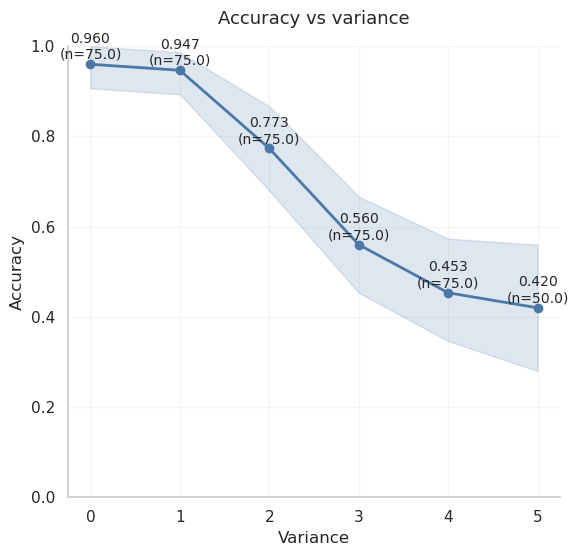

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

assert 'df_trials' in globals() and not df_trials.empty, "Run the data loading cell first."

# Style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (6, 6),
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
out_dir = "/scratch/gpfs/nb0564/vlm_reasoning/plots"
os.makedirs(out_dir, exist_ok=True)

def bootstrap_ci_mean(binary_series, n_boot=2000, alpha=0.05):
    a = binary_series.astype(int).values
    if a.size == 0:
        return np.nan, np.nan, np.nan
    boots = np.random.choice(a, size=(n_boot, a.size), replace=True).mean(axis=1)
    return float(a.mean()), float(np.percentile(boots, 100*alpha/2)), float(np.percentile(boots, 100*(1-alpha/2)))

# Fix logical dim to 3; fallback if missing
target_dim_for_var = 3 if (df_trials['logical_dim'] == 3).any() else int(df_trials['logical_dim'].max())

sub = df_trials[df_trials['logical_dim'] == target_dim_for_var]
pts = []
for v in sorted(sub['var'].unique()):
    ser = sub[sub['var'] == v]['correct']
    if ser.empty:
        continue
    m, lo, hi = bootstrap_ci_mean(ser, n_boot=2000, alpha=0.05)
    pts.append((v, m, lo, hi, len(ser)))
P = pd.DataFrame(pts, columns=['var','mean','lo','hi','n'])

# Plot
fig, ax = plt.subplots()
if not P.empty:
    neutral = "#4C78A8"
    ax.plot(P['var'], P['mean'], color=neutral, marker='o', lw=2)
    ax.fill_between(P['var'], P['lo'], P['hi'], color=neutral, alpha=0.18)
    for _, r in P.iterrows():
        ax.text(r['var'], r['mean'] + 0.012, f"{r['mean']:.3f}\n(n={r['n']})", ha='center', fontsize=10)
ax.set_title("Accuracy vs variance", pad=16)
ax.set_xlabel("Variance")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
sns.despine(ax=ax)
plt.tight_layout(pad=1.2, rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(out_dir, "acc_v_var.pdf"), bbox_inches="tight")
plt.show()

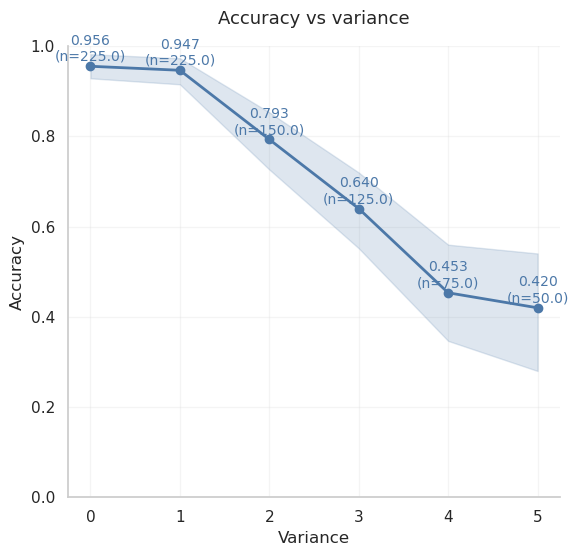

In [22]:
# Cell 3 — Accuracy vs variance aggregated across ALL dimensions (concatenate trials for each var)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

assert 'df_trials' in globals() and not df_trials.empty, "Run the data loading cell first."

# Aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (6, 6),
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
out_dir = "/scratch/gpfs/nb0564/vlm_reasoning/plots"
os.makedirs(out_dir, exist_ok=True)

def bootstrap_ci_mean(binary_series, n_boot=2000, alpha=0.05):
    a = binary_series.astype(int).values
    if a.size == 0:
        return np.nan, np.nan, np.nan
    boots = np.random.choice(a, size=(n_boot, a.size), replace=True).mean(axis=1)
    return float(a.mean()), float(np.percentile(boots, 100*alpha/2)), float(np.percentile(boots, 100*(1-alpha/2)))

# Aggregate across ALL logical dims at each variance
vars_sorted = sorted(df_trials['var'].unique())
rows = []
for v in vars_sorted:
    s = df_trials[df_trials['var'] == v]['correct']
    if s.empty:
        continue
    m, lo, hi = bootstrap_ci_mean(s, n_boot=2000, alpha=0.05)
    rows.append((v, m, lo, hi, len(s)))
P = pd.DataFrame(rows, columns=['var','mean','lo','hi','n']).sort_values('var')

# Plot
fig, ax = plt.subplots()
color = "#4C78A8"  # neutral, journal-friendly
if not P.empty:
    ax.plot(P['var'], P['mean'], color=color, marker='o', lw=2)
    ax.fill_between(P['var'], P['lo'], P['hi'], color=color, alpha=0.18)
    for _, r in P.iterrows():
        ax.text(r['var'], r['mean'] + 0.012, f"{r['mean']:.3f}\n(n={r['n']})", ha='center', fontsize=10, color=color)

ax.set_title("Accuracy vs variance", pad=16)
ax.set_xlabel("Variance")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
sns.despine(ax=ax)

plt.tight_layout(pad=1.2, rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(out_dir, "acc_v_var_agg.pdf"), bbox_inches="tight")
plt.show()